In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [8]:
df.info()

print("\nТипы данных столбцов:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB

Типы данных столбцов:
Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

print(df.head())

df.info()

print("\nТипы данных столбцов:")
print(df.dtypes)

        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB

Типы данных столбцов:
Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатур

Сгруппируйте данные по дате, посчитайте количество продаж

In [10]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [11]:
print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

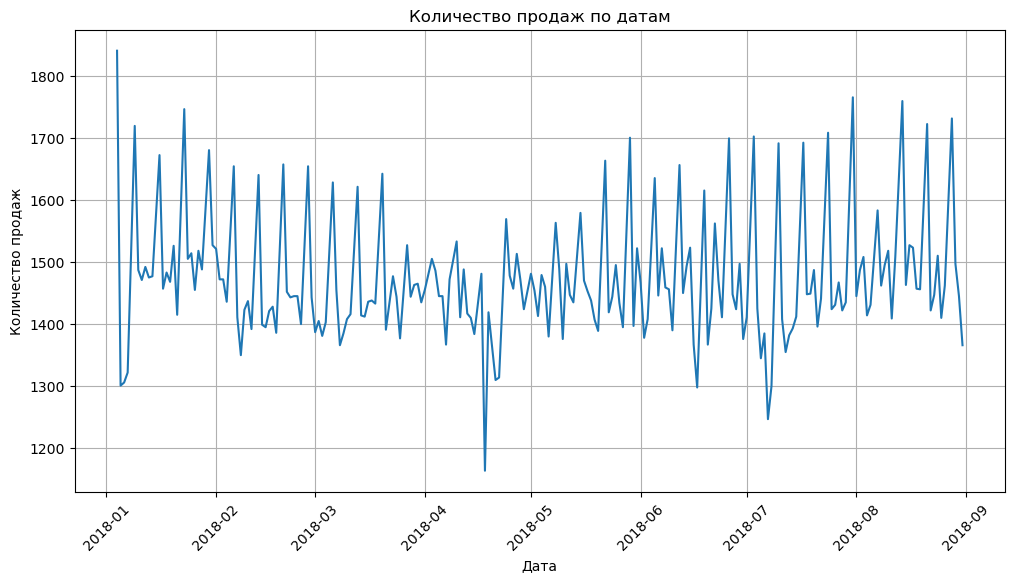

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'])

plt.title('Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике представлена динамика количества продаж по датам за анализируемый период.
По оси X отображены даты продаж, по оси Y — количество продаж (число записей) за каждый день.
График показывает изменение активности продаж во времени. В течение периода наблюдаются колебания количества продаж: в отдельные дни продажи увеличиваются, в другие — снижаются. Это свидетельствует о неравномерном спросе на товары.
Можно отметить наличие локальных пиков и спадов. Пиковые значения соответствуют дням с наиболее высокой активностью покупателей, а минимальные значения отражают периоды снижения спроса.
Если на графике отсутствует ярко выраженный восходящий или нисходящий тренд, это говорит о том, что общий уровень продаж остается относительно стабильным, несмотря на ежедневные колебания.
Также следует обратить внимание на возможную сезонность. Если пики повторяются через одинаковые промежутки времени (например, еженедельно), это может указывать на влияние дней недели на объем продаж.
Для более глубокого анализа рекомендуется дополнительно изучить продажи по месяцам, дням недели и категориям товаров, чтобы выявить факторы, влияющие на изменение спроса.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

max_date = grouped_df.loc[
    grouped_df['Количество продаж'].idxmax(),
    'Дата'
]

print(max_date)

2018-01-04 00:00:00


In [14]:
outlier_row = grouped_df.loc[grouped_df['Количество продаж'].idxmax()]

print(outlier_row)

Дата                 2018-01-04 00:00:00
Количество продаж                   1840
Name: 0, dtype: object


In [15]:
outlier_df = df[df['Дата'] == max_date]

print(outlier_df)

           Дата  Склад   Контрагент Номенклатура  Количество
0    2018-01-04      1    address_0    product_0           4
1    2018-01-04      1    address_0    product_1           4
2    2018-01-04      1    address_0    product_2           5
3    2018-01-04      1    address_0    product_3          10
4    2018-01-04      1    address_0    product_4           2
...         ...    ...          ...          ...         ...
1835 2018-01-04      5  address_174    product_5           0
1836 2018-01-04      5  address_174    product_6           0
1837 2018-01-04      5  address_174   product_10           1
1838 2018-01-04      5  address_174   product_22           4
1839 2018-01-04      5  address_174   product_15           0

[1840 rows x 5 columns]


In [16]:
print(grouped_df.loc[grouped_df['Количество продаж'].idxmax()])

Дата                 2018-01-04 00:00:00
Количество продаж                   1840
Name: 0, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [17]:
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.day_name()

filtered_df = df[
    (df['Месяц'].isin([6, 7, 8])) &
    (df['День_недели'] == 'Wednesday') &
    (df['Склад'] == 3)
]

top_products = (
    filtered_df
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
)

print("Топовый товар:")
print(top_products.head(1))

Топовый товар:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [1]:
!pip install xlrd

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [1]:
import pandas as pd

weather_df = pd.read_excel('weather.xls', engine='xlrd')

print(weather_df.head())

        Дата     T
0 2018-08-31   9.6
1 2018-08-31  11.3
2 2018-08-31  12.3
3 2018-08-31  13.2
4 2018-08-31  12.5


In [2]:
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'])

In [3]:
weather_daily = (
    weather_df
    .groupby('Дата', as_index=False)
    .agg({'T': 'mean'})
)

print(weather_daily.head())

        Дата        T
0 2018-01-04 -13.0875
1 2018-01-05 -17.2500
2 2018-01-06 -14.1250
3 2018-01-07 -12.3375
4 2018-01-08 -15.4375


In [18]:
grouped_df = (
    df.groupby('Дата')
      .size()
      .reset_index(name='Количество продаж')
)

print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


In [19]:
merged_df = pd.merge(
    grouped_df,
    weather_daily,
    on='Дата',
    how='inner'
)

print(merged_df.head())

        Дата  Количество продаж        T
0 2018-01-04               1840 -13.0875
1 2018-01-05               1301 -17.2500
2 2018-01-06               1306 -14.1250
3 2018-01-07               1322 -12.3375
4 2018-01-09               1719  -7.3875


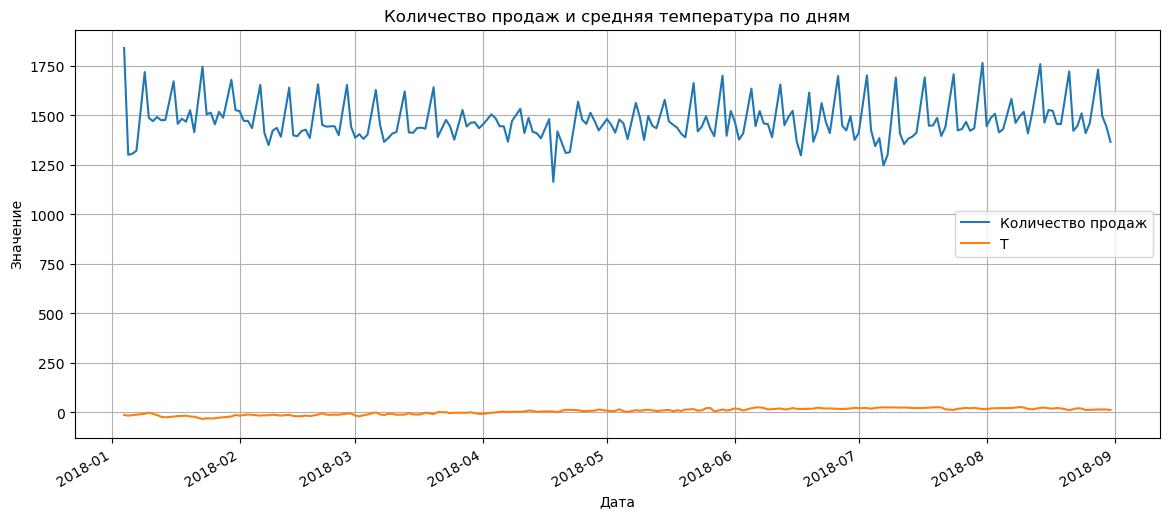

In [20]:
merged_df.plot(
    x='Дата',
    y=['Количество продаж', 'T'],
    figsize=(14, 6),
    grid=True
)

plt.title('Количество продаж и средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.show()

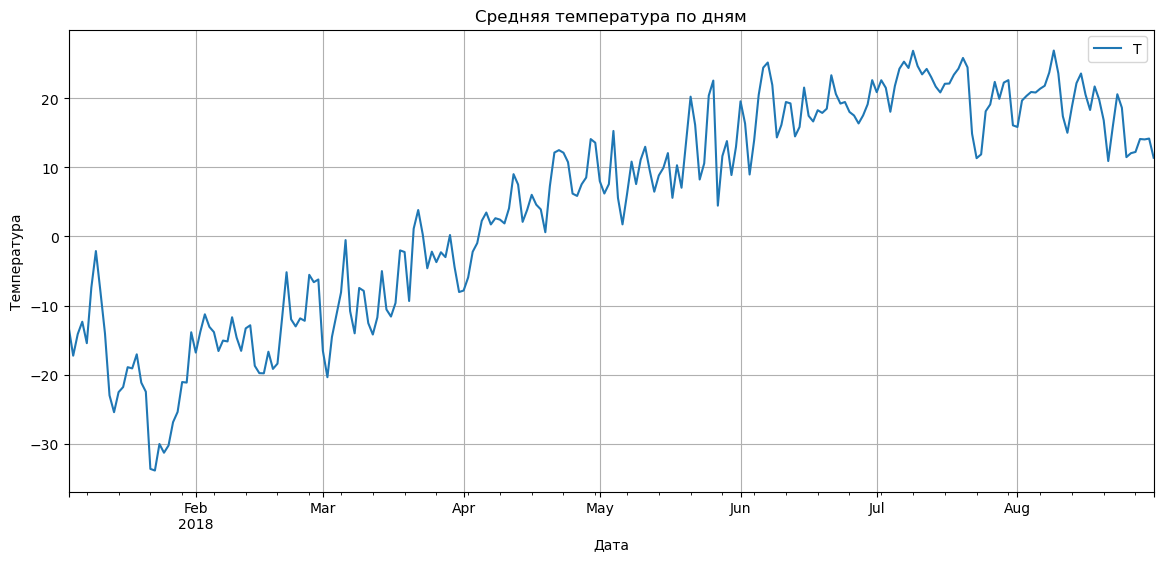

In [21]:
weather_daily.plot(
    x='Дата',
    y='T',
    figsize=(14, 6),
    grid=True
)

plt.title('Средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.show()